<a href="https://colab.research.google.com/github/CauaMaia/processamento_de_imagens/blob/main/histogramas_realce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de Imagens — Histograma e Realce de Contraste

Trabalho da aula 04. Três fotos pessoais: uma subexposta (noturna), uma com sol
direto / estourada e uma bem exposta.

Para cada uma: conversão para tons de cinza, histograma, diagnóstico, **uma**
operação de realce (expansão de contraste, equalização ou correção de gamma) e
figura antes/depois com os dois histogramas.

## 1. Setup e upload das imagens

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

CAMINHOS = {
    "escura": "foto_escura.jpeg",
    "clara":  "foto_clara.jpeg",
    "boa":    "foto_boa.jpeg",
}

# No Colab: roda o upload se os arquivos ainda nao estiverem na sessao.
if not all(os.path.exists(p) for p in CAMINHOS.values()):
    try:
        from google.colab import files
        print("Suba os 3 arquivos:", ", ".join(CAMINHOS.values()))
        files.upload()
    except ImportError:
        pass

for nome, caminho in CAMINHOS.items():
    print(nome, "->", caminho, "OK" if os.path.exists(caminho) else "NAO ENCONTRADO")

Suba os 3 arquivos: foto_escura.jpeg, foto_clara.jpeg, foto_boa.jpeg


Saving foto_boa.jpeg to foto_boa.jpeg
Saving foto_clara.jpeg to foto_clara.jpeg
Saving foto_escura.jpeg to foto_escura.jpeg
escura -> foto_escura.jpeg OK
clara -> foto_clara.jpeg OK
boa -> foto_boa.jpeg OK


## 2. Funções da aula

Reaproveitadas dos códigos da aula (versões vetorizadas em NumPy). A equalização
usa a função pronta do OpenCV.

In [2]:
def histograma(imagem, titulo="Histograma", ax=None):
    """Plota o histograma de uma imagem em tons de cinza (uint8)."""
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(imagem.ravel(), bins=256, range=(0, 256), color="#444")
    ax.set_xlim(0, 255)
    ax.set_xlabel("Nivel de cinza")
    ax.set_ylabel("Qtd. de pixels")
    ax.set_title(titulo)
    return ax


def expandir_contraste(imagem):
    """Mapeia linearmente [L, H] -> [0, 255]. Retorna (imagem, L, H)."""
    L, H = int(imagem.min()), int(imagem.max())
    if H == L:
        return imagem.copy(), L, H
    resultado = (imagem.astype(float) - L) * 255 / (H - L)
    return resultado.astype(np.uint8), L, H


def equalizar(imagem):
    """Equalizacao de histograma (OpenCV)."""
    return cv2.equalizeHist(imagem)


def corrigir_gamma(imagem, gamma):
    """s = 255 * (r/255)^gamma.  gamma < 1 clareia, gamma > 1 escurece."""
    if gamma <= 0:
        raise ValueError("gamma deve ser maior que zero.")
    return (255 * ((imagem / 255.0) ** gamma)).astype(np.uint8)


def carregar_cinza(caminho):
    img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(caminho)
    return img


def resumo(imagem, nome=""):
    """Estatisticas rapidas para embasar o diagnostico."""
    print(f"{nome}: min={imagem.min()}  max={imagem.max()}  "
          f"media={imagem.mean():.1f}  mediana={np.median(imagem):.0f}  "
          f"desvio={imagem.std():.1f}")
    print(f"  pixels < 50: {(imagem < 50).mean()*100:.1f}%   "
          f"pixels > 200: {(imagem > 200).mean()*100:.1f}%   "
          f"pixels == 0: {(imagem == 0).mean()*100:.2f}%   "
          f"pixels == 255: {(imagem == 255).mean()*100:.2f}%")

In [3]:
def comparar(original, processada, titulo, rotulo_op):
    """Figura 2x2: antes/depois em cima, histogramas embaixo."""
    fig, eixos = plt.subplots(2, 2, figsize=(11, 8))

    eixos[0, 0].imshow(original, cmap="gray", vmin=0, vmax=255)
    eixos[0, 0].set_title("Antes (tons de cinza)")
    eixos[0, 0].axis("off")

    eixos[0, 1].imshow(processada, cmap="gray", vmin=0, vmax=255)
    eixos[0, 1].set_title(f"Depois - {rotulo_op}")
    eixos[0, 1].axis("off")

    histograma(original, "Histograma antes", eixos[1, 0])
    histograma(processada, "Histograma depois", eixos[1, 1])

    fig.suptitle(titulo, fontsize=14)
    fig.tight_layout()
    plt.show()

    mae = np.abs(processada.astype(int) - original.astype(int)).mean()
    print(f"Diferenca media absoluta (MAE) entre antes e depois: {mae:.2f} niveis")
    return mae

## 3. Imagem 1 — subexposta (retrato noturno)

escura: min=0  max=255  media=45.7  mediana=22  desvio=59.2
  pixels < 50: 72.4%   pixels > 200: 4.0%   pixels == 0: 13.63%   pixels == 255: 0.01%


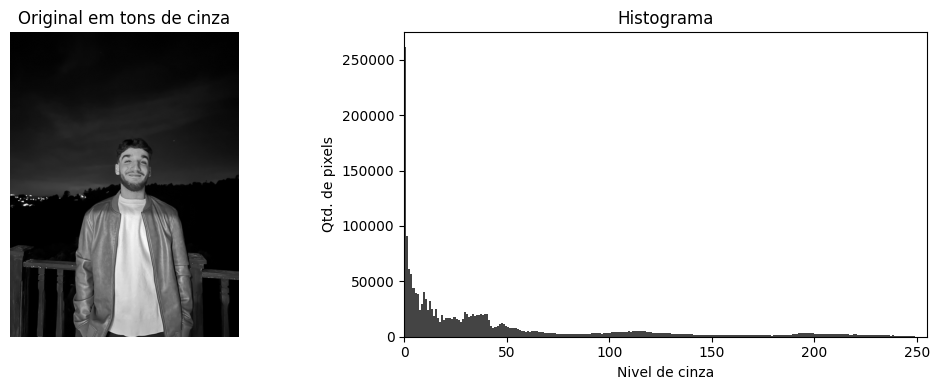

In [4]:
img_escura = carregar_cinza(CAMINHOS["escura"])
resumo(img_escura, "escura")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_escura, cmap="gray", vmin=0, vmax=255); ax[0].axis("off")
ax[0].set_title("Original em tons de cinza")
histograma(img_escura, "Histograma", ax[1])
plt.tight_layout(); plt.show()

**Diagnóstico.** Quase toda a massa do histograma está espremida na faixa
0–60 (≈72% dos pixels abaixo de 50 e ≈14% exatamente em 0), com uma cauda fina
até 255 que corresponde só às luzes da cidade ao fundo. É o formato clássico de
imagem subexposta: o rosto e a jaqueta ocupam pouquíssimos níveis de cinza, então
há detalhe registrado, mas comprimido demais para ser visível.

**Operação escolhida: correção de gamma, γ = 0,45.** Expansão de contraste não
resolveria nada aqui, porque a imagem já vai de 0 a 255 (o mapeamento seria quase
a identidade). A equalização resolveria, mas de forma agressiva: como 14% dos
pixels estão em 0, ela estica muito a faixa escura e escancara o ruído do sensor.
O gamma < 1 clareia os tons baixos de forma não linear, abrindo as sombras sem
estourar as luzes já claras.

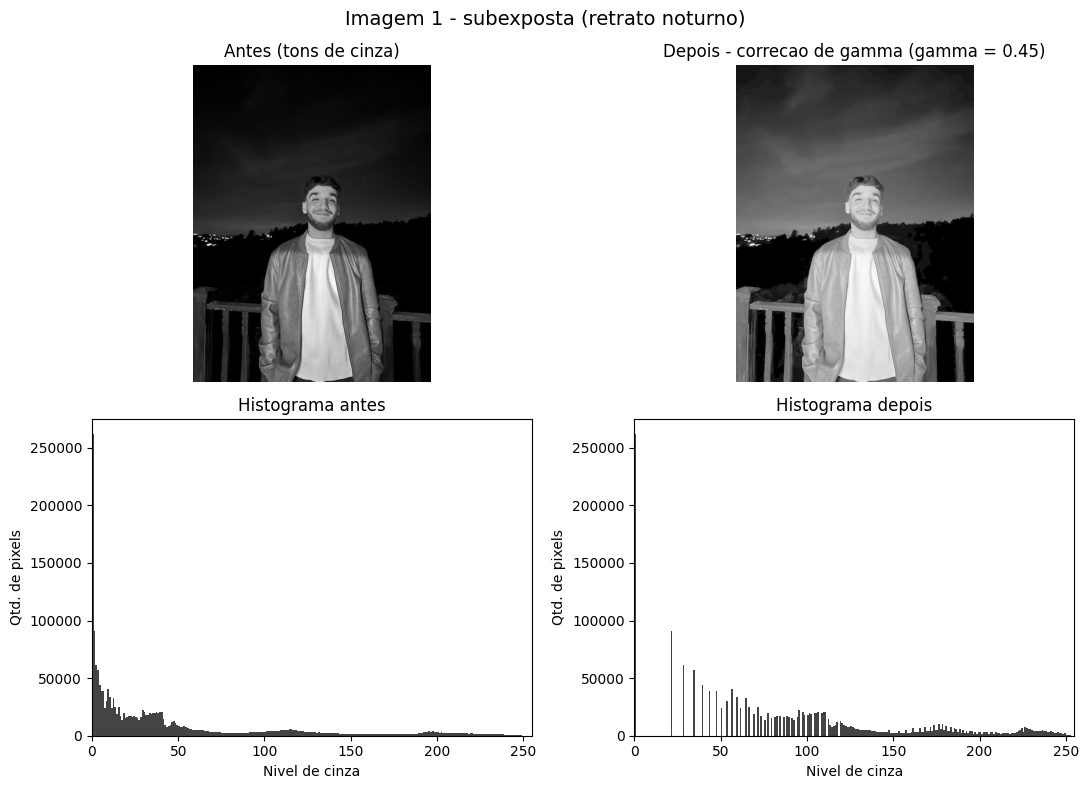

Diferenca media absoluta (MAE) entre antes e depois: 45.48 niveis


In [5]:
GAMMA_ESCURA = 0.45
escura_corrigida = corrigir_gamma(img_escura, GAMMA_ESCURA)

mae_escura = comparar(
    img_escura, escura_corrigida,
    "Imagem 1 - subexposta (retrato noturno)",
    f"correcao de gamma (gamma = {GAMMA_ESCURA})",
)

## 4. Imagem 2 — sol direto / luzes estouradas

clara: min=1  max=255  media=113.3  mediana=113  desvio=62.3
  pixels < 50: 19.5%   pixels > 200: 9.6%   pixels == 0: 0.00%   pixels == 255: 0.34%


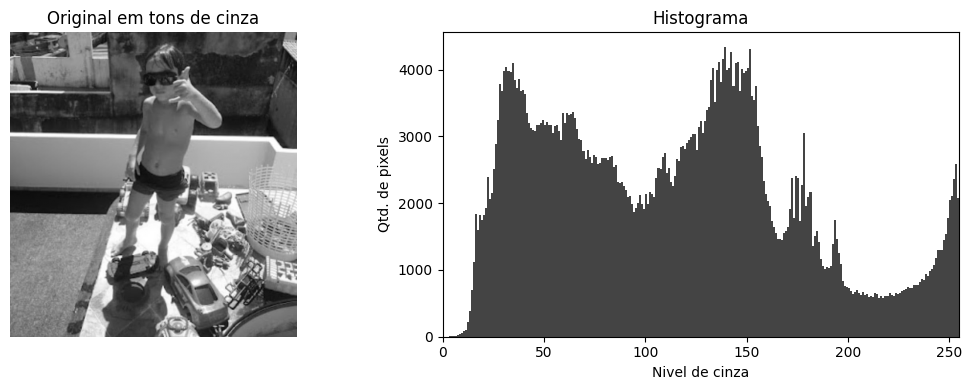

In [6]:
img_clara = carregar_cinza(CAMINHOS["clara"])
resumo(img_clara, "clara")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_clara, cmap="gray", vmin=0, vmax=255); ax[0].axis("off")
ax[0].set_title("Original em tons de cinza")
histograma(img_clara, "Histograma", ax[1])
plt.tight_layout(); plt.show()

**Diagnóstico.** O histograma é bimodal, com um modo em torno de 40 (as
sombras duras do sol a pino) e outro, mais alto, em torno de 140 (o piso e a
parede batidos pelo sol). Quase 10% dos pixels estão acima de 200 e há um pico
colado em 255 (0,34% da imagem): área realmente estourada, onde a informação foi
perdida de vez. É o padrão de cena de alto contraste ao meio-dia — em vez de
concentrar tudo no claro, a foto joga os pixels nos dois extremos e esvazia a
faixa 160–240.

**Operação escolhida: correção de gamma, γ = 1,4.** A imagem já ocupa toda a faixa
(1–255), então expansão de contraste seria a identidade. A equalização pioraria o
problema: ela empurraria ainda mais pixels para os extremos já saturados. Com
γ > 1 os tons médios-altos são comprimidos para baixo, o que devolve textura ao
piso e à parede iluminados sem alterar o que já é preto. Testei γ = 1,2, 1,4 e 1,6;
com 1,6 a imagem fica escura demais, e 1,4 foi o melhor equilíbrio.

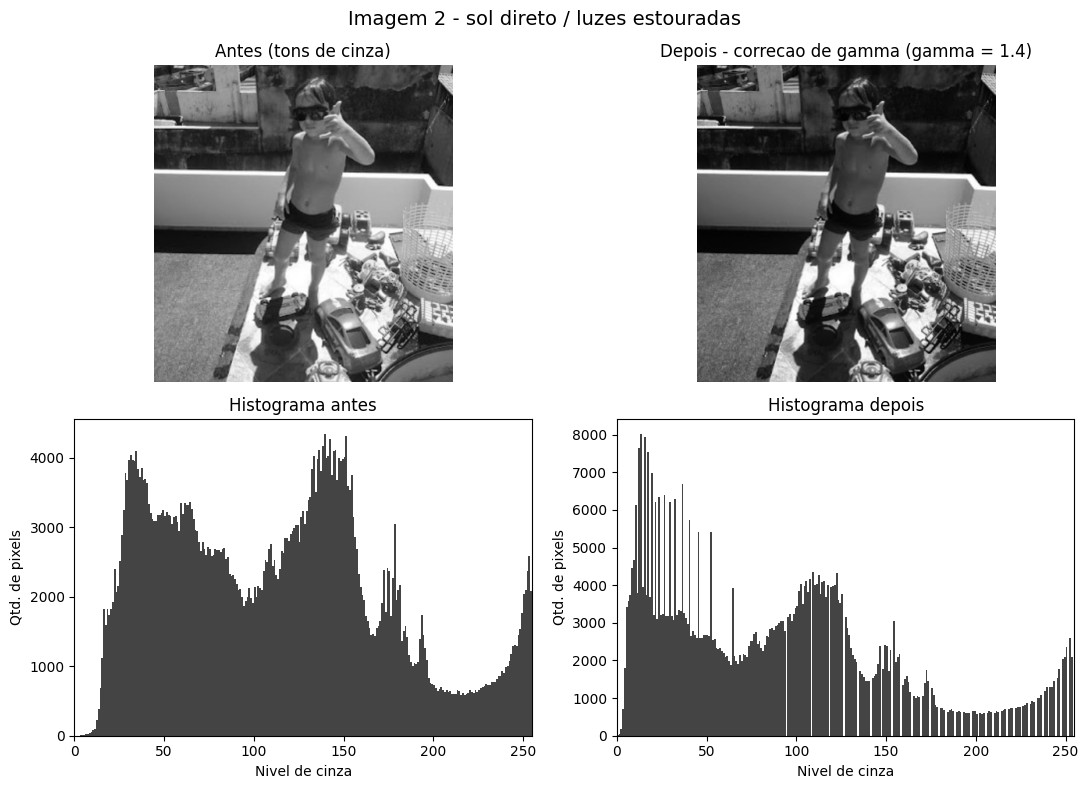

Diferenca media absoluta (MAE) entre antes e depois: 24.91 niveis


In [7]:
GAMMA_CLARA = 1.4
clara_corrigida = corrigir_gamma(img_clara, GAMMA_CLARA)

mae_clara = comparar(
    img_clara, clara_corrigida,
    "Imagem 2 - sol direto / luzes estouradas",
    f"correcao de gamma (gamma = {GAMMA_CLARA})",
)

## 5. Imagem 3 — bem exposta

boa: min=9  max=255  media=87.6  mediana=59  desvio=60.0
  pixels < 50: 30.4%   pixels > 200: 11.9%   pixels == 0: 0.00%   pixels == 255: 0.45%


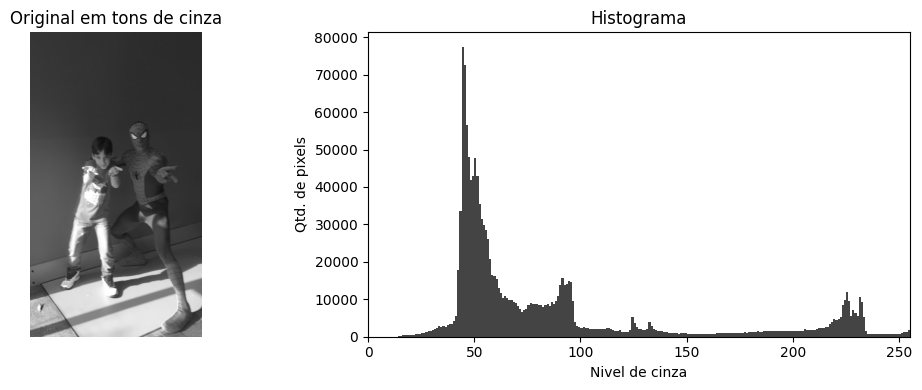

In [8]:
img_boa = carregar_cinza(CAMINHOS["boa"])
resumo(img_boa, "boa")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_boa, cmap="gray", vmin=0, vmax=255); ax[0].axis("off")
ax[0].set_title("Original em tons de cinza")
histograma(img_boa, "Histograma", ax[1])
plt.tight_layout(); plt.show()

**Diagnóstico.** O histograma cobre a faixa inteira (min = 9, max = 255), sem
pixels grudados em 0 e com pouquíssimos em 255. O pico acentuado entre 32 e 64 não
é subexposição: é a parede verde uniforme do fundo, que vira um cinza médio-escuro
na conversão. O assunto (pele, camisa vermelha, tênis brancos) aparece distribuído
no resto da faixa, o que indica exposição correta.

**Operação escolhida: expansão de contraste, L = 9 e H = 255.** É a operação
natural para testar uma imagem que já parece bem exposta, justamente porque ela
mede o quanto a faixa dinâmica está sendo aproveitada. Como L e H já estão
praticamente nos extremos, o mapeamento linear é quase a identidade — e é esse o
resultado esperado.

L = 9, H = 255


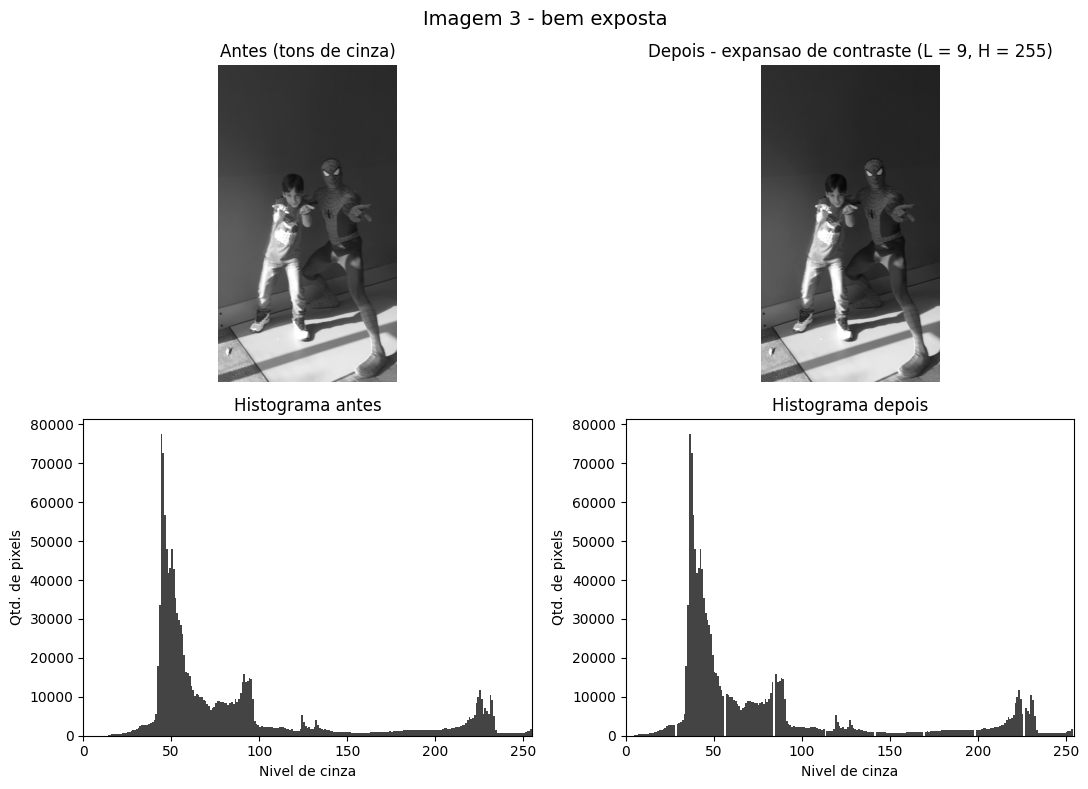

Diferenca media absoluta (MAE) entre antes e depois: 6.60 niveis


In [9]:
boa_corrigida, L, H = expandir_contraste(img_boa)
print(f"L = {L}, H = {H}")

mae_boa = comparar(
    img_boa, boa_corrigida,
    "Imagem 3 - bem exposta",
    f"expansao de contraste (L = {L}, H = {H})",
)

## 6. Comparação final

In [10]:
print(f"{'Imagem':<22}{'Operacao':<32}{'MAE':>8}")
print("-" * 62)
print(f"{'1 - subexposta':<22}{'gamma = 0.45':<32}{mae_escura:>8.2f}")
print(f"{'2 - estourada':<22}{'gamma = 1.40':<32}{mae_clara:>8.2f}")
print(f"{'3 - bem exposta':<22}{f'expansao (L={L}, H={H})':<32}{mae_boa:>8.2f}")

Imagem                Operacao                             MAE
--------------------------------------------------------------
1 - subexposta        gamma = 0.45                       45.48
2 - estourada         gamma = 1.40                       24.91
3 - bem exposta       expansao (L=9, H=255)               6.60


## 7. Conclusão

A operação fez muito menos diferença na terceira imagem, a bem exposta: a
diferença média absoluta ficou em torno de 6,6 níveis de cinza, contra ~45 na
noturna e ~25 na de sol direto. O motivo está no próprio histograma — ela já ia
de 9 a 255, ou seja, já usava praticamente toda a faixa dinâmica disponível, e a
expansão de contraste só consegue esticar o que está espremido. Com L = 9 e
H = 255, o mapeamento linear vira quase a função identidade: cada pixel se desloca
uns poucos níveis e a forma do histograma continua igual, apenas com os vales
característicos da requantização. É o resultado esperado e serve como controle do
experimento: quando a exposição está correta, não há o que corrigir, e insistir em
realce (uma equalização, por exemplo) só distorceria os tons da cena sem ganho de
informação. Já nas outras duas a massa do histograma estava concentrada em um dos
extremos, e por isso o gamma teve muito espaço para redistribuir os níveis.